In [12]:
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm

file_path = "movies.csv"
df = pd.read_csv(file_path, encoding="latin1")

Note: you may need to restart the kernel to use updated packages.


## **1. Exploración rápida del dataset**

In [3]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")

In [4]:
print("\nInformación general del dataset:")
print(df.info())

In [5]:
print("\nEstadísticas descriptivas de las variables numéricas:")
print(df.describe())

In [6]:
# Calcular el porcentaje de valores nulos
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Filtrar solo las columnas con valores nulos
missing_percentage = missing_percentage[missing_percentage > 0]

print("\nPorcentaje de valores nulos en el dataset:")
print(missing_percentage)

In [7]:
plt.figure(figsize=(12, 6))
missing_percentage.sort_values().plot(kind='barh', color='darkblue')

plt.xlabel("Porcentaje de valores nulos")
plt.ylabel("Columnas")
plt.title("Porcentaje de valores nulos por columna")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [8]:
# calcular el promedio de la popularidad de actores por película

def calcular_promedio_popularidad(val):
    if isinstance(val, str):  
        valores = [float(i) for i in val.strip('|').split('|') if i.replace('.', '', 1).isdigit()]  
        return np.mean(valores) if valores else np.nan  
    return np.nan  

df['actorsPopularity'] = df['actorsPopularity'].apply(calcular_promedio_popularidad)

print(df['actorsPopularity'].head(10))  
print("Valores únicos en 'actorsPopularity':", df['actorsPopularity'].nunique())

## **2. Clasificación de las variables del dataset**

In [ ]:
df['castWomenAmount'] = pd.to_numeric(df['castWomenAmount'], errors='coerce').astype('Int64')
df['castMenAmount'] = pd.to_numeric(df['castMenAmount'], errors='coerce').astype('Int64')

qualitative_nominal = []  
qualitative_ordinal = [] 
quantitative_continuous = []  
quantitative_discrete = [] 


for column in df.columns:
    if df[column].dtype == 'object':  # Variables categóricas (texto)
        qualitative_nominal.append(column)
    elif df[column].dtype in ['int64', 'Int64', 'float64']:  # Variables numéricas
        unique_values = df[column].nunique()
        if unique_values < 10:  # Se considera ordinal si tiene pocos valores únicos
            qualitative_ordinal.append(column)
        elif df[column].dtype in ['int64', 'Int64']:  # Variables discretas (enteros)
            quantitative_discrete.append(column)
        else:  # Variables continuas (decimales)
            quantitative_continuous.append(column)


print(f"Cualitativas nominales ({len(qualitative_nominal)}): {qualitative_nominal}")
print(f"Cualitativas ordinales ({len(qualitative_ordinal)}): {qualitative_ordinal}")
print(f"Cuantitativas continuas ({len(quantitative_continuous)}): {quantitative_continuous}")
print(f"Cuantitativas discretas ({len(quantitative_discrete)}): {quantitative_discrete}")


Cualitativas nominales (13): ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 'productionCountry', 'video', 'director', 'actors', 'actorsCharacter', 'originalTitle', 'title', 'originalLanguage', 'releaseDate']
Cualitativas ordinales (0): []
Cuantitativas continuas (4): ['revenue', 'actorsPopularity', 'popularity', 'voteAvg']
Cuantitativas discretas (10): ['id', 'budget', 'runtime', 'voteCount', 'genresAmount', 'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 'castWomenAmount', 'castMenAmount']


## **3. Las variables cuantitativas siguen una distribución normal?**

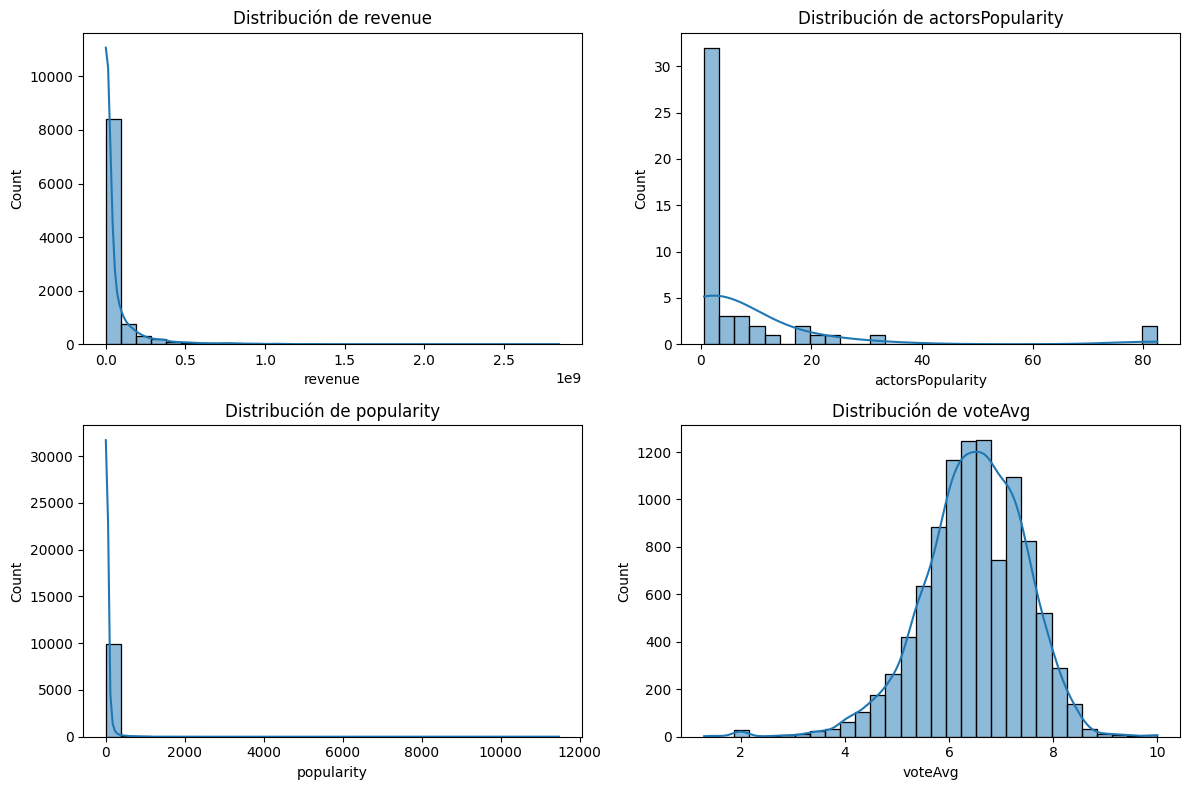

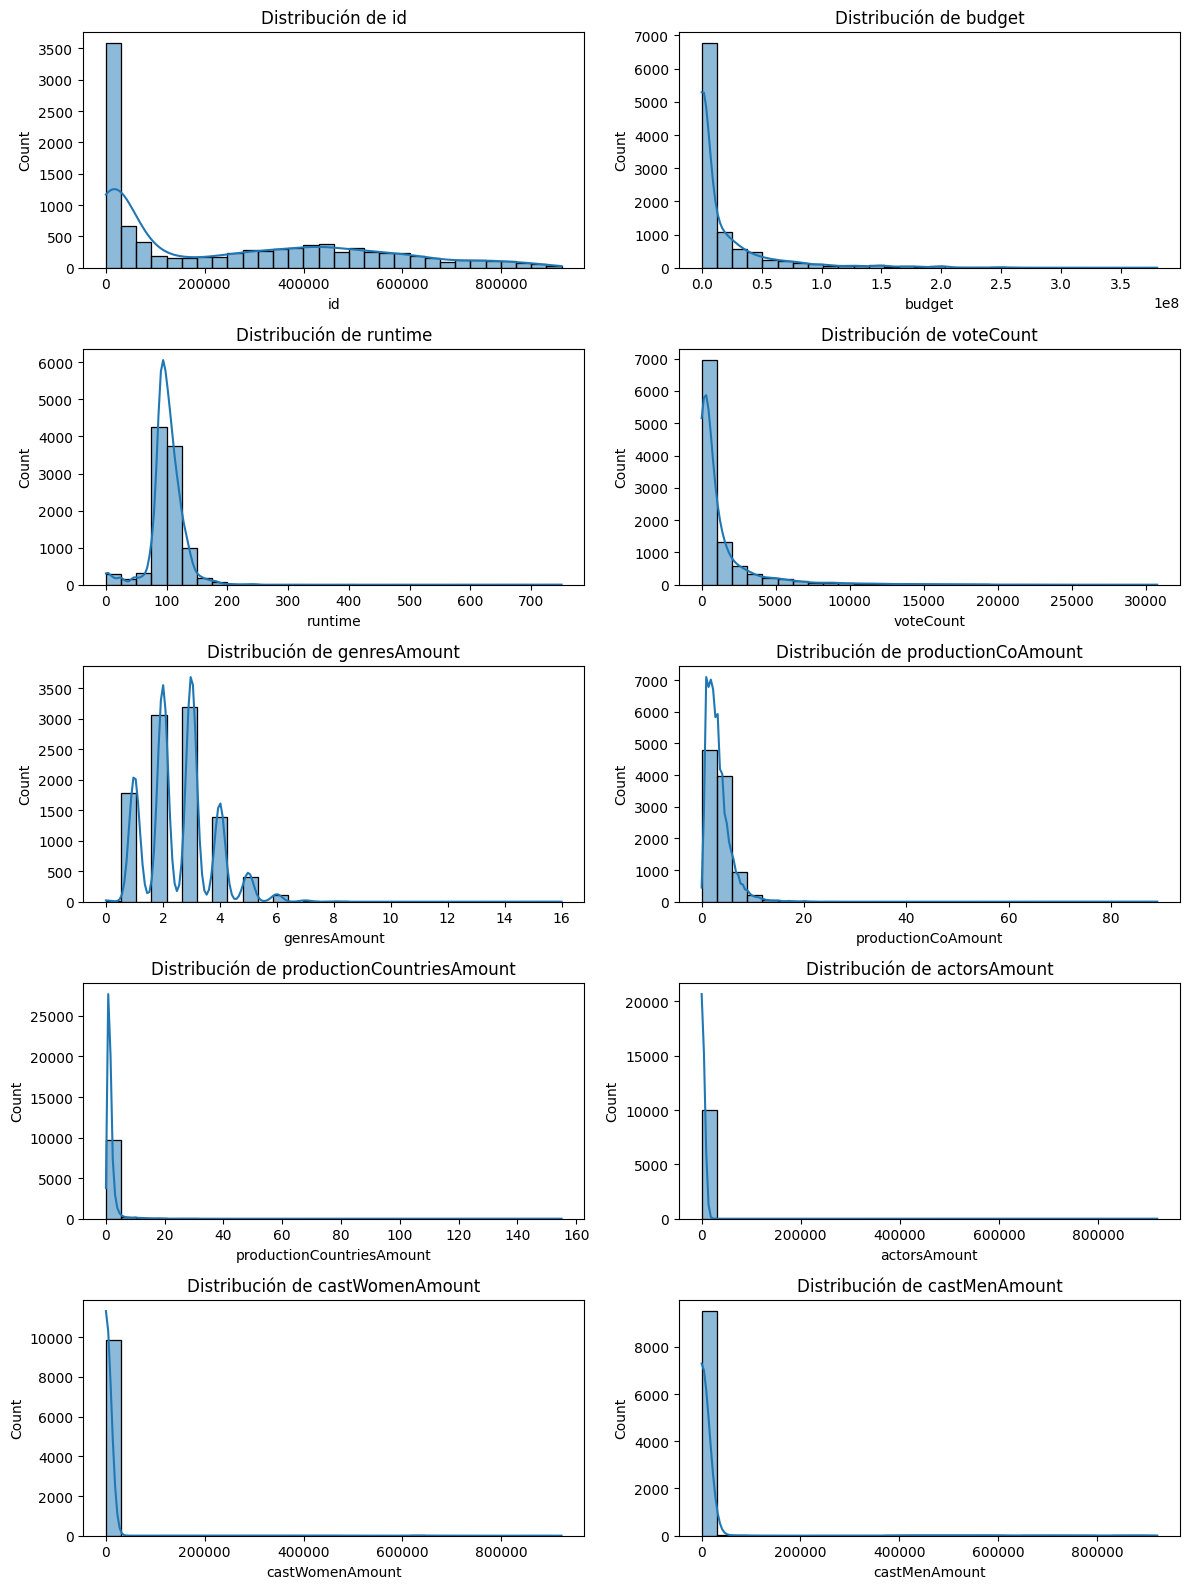

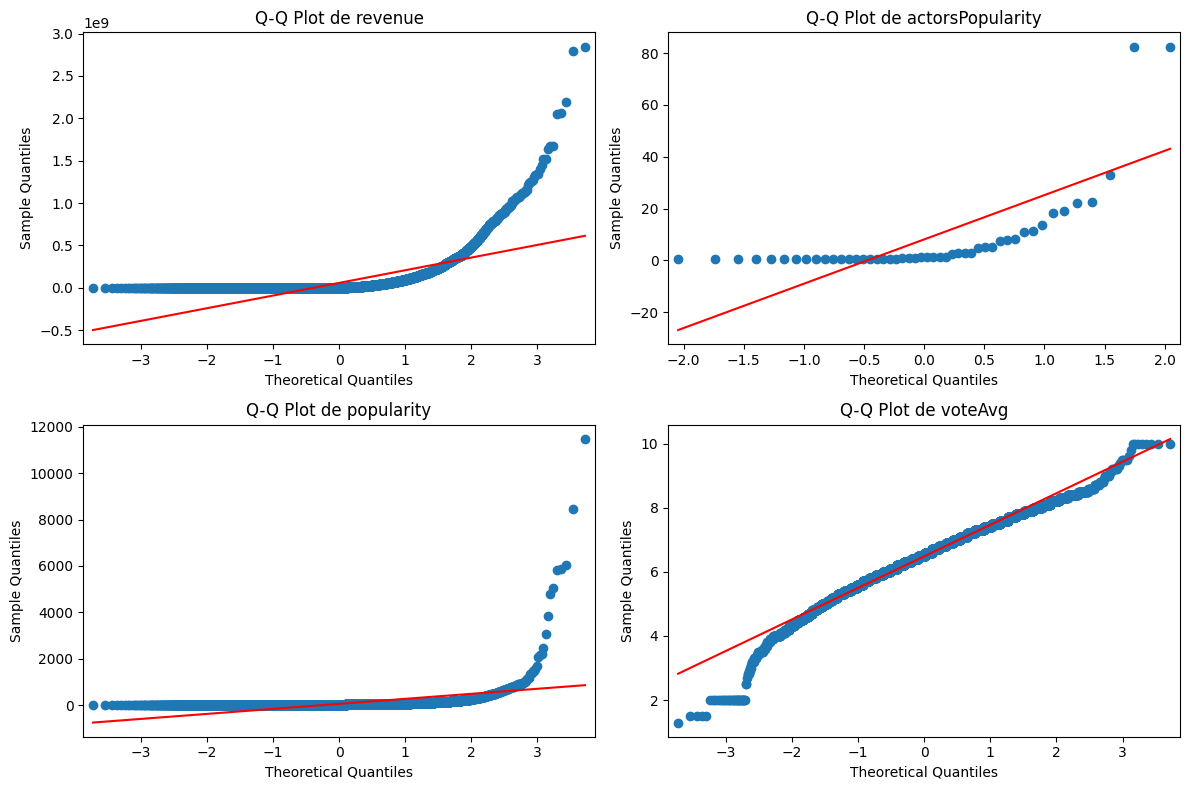

Resultados de la prueba de Kolmogorov-Smirnov para variables continuas:


,Statistic,P-Value,Normal
revenue,0.352232,0.0,False
actorsPopularity,0.332019,0.000032,False
popularity,0.417335,0.0,False
voteAvg,0.04591,0.0,False



Resultados de la prueba de Kolmogorov-Smirnov para variables discretas:


,Statistic,P-Value,Normal
id,0.200786,0.0,False
budget,0.306251,0.0,False
runtime,0.14408,0.0,False
voteCount,0.300445,0.0,False
genresAmount,0.183598,0.0,False
productionCoAmount,0.200403,0.0,False
productionCountriesAmount,0.392653,0.0,False
actorsAmount,0.516689,0.0,False
castWomenAmount,0.52831,0.0,False
castMenAmount,0.52814,0.0,False


In [21]:
quantitative_continuous_vars = ['revenue', 'actorsPopularity', 'popularity', 'voteAvg']
quantitative_discrete_vars = ['id', 'budget', 'runtime', 'voteCount', 'genresAmount', 
                              'productionCoAmount', 'productionCountriesAmount', 'actorsAmount', 
                              'castWomenAmount', 'castMenAmount']

for var in quantitative_continuous_vars + quantitative_discrete_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')

# Aplicar la prueba de Kolmogorov-Smirnov para normalidad
def ks_test(variable):
    clean_data = df[variable].dropna()
    if len(clean_data) >= 3:
        stat, p_value = stats.kstest(clean_data, 'norm', args=(clean_data.mean(), clean_data.std()))
        return {'Statistic': stat, 'P-Value': p_value, 'Normal': p_value > 0.05}
    else:
        return {'Statistic': np.nan, 'P-Value': np.nan, 'Normal': np.nan}

normality_results_continuous = {var: ks_test(var) for var in quantitative_continuous_vars}
normality_results_discrete = {var: ks_test(var) for var in quantitative_discrete_vars}

normality_df_continuous = pd.DataFrame(normality_results_continuous).T
normality_df_discrete = pd.DataFrame(normality_results_discrete).T

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(quantitative_continuous_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(5, 2, figsize=(12, 16))
axes = axes.flatten()
for i, var in enumerate(quantitative_discrete_vars):
    sns.histplot(df[var].dropna(), kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(quantitative_continuous_vars):
    sm.qqplot(df[var].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f'Q-Q Plot de {var}')
plt.tight_layout()
plt.show()


print("Resultados de la prueba de Kolmogorov-Smirnov para variables continuas:")
display(normality_df_continuous)

print("\nResultados de la prueba de Kolmogorov-Smirnov para variables discretas:")
display(normality_df_discrete)



## Prueba para verificar sesgos

In [22]:
skewness_kurtosis = df[quantitative_continuous_vars + quantitative_discrete_vars].skew().to_frame(name="Skewness")
skewness_kurtosis["Kurtosis"] = df[quantitative_continuous_vars + quantitative_discrete_vars].kurtosis()
display(skewness_kurtosis)


,Skewness,Kurtosis
revenue,5.919857,55.932018
actorsPopularity,3.602379,13.606202
popularity,30.378934,1226.192397
voteAvg,-0.577800,1.487066
id,0.681957,-0.790283
budget,3.244864,13.218236
runtime,0.971990,35.554741
voteCount,4.147104,22.782155
genresAmount,0.691445,2.107499
productionCoAmount,5.988578,140.372931


## Tabla de frecuencias de las variables cualitativas

In [24]:
qualitative_nominal_vars = ['genres', 'homePage', 'productionCompany', 'productionCompanyCountry', 
                            'productionCountry', 'video', 'director', 'actors', 'actorsCharacter', 
                            'originalTitle', 'title', 'originalLanguage', 'releaseDate']

def count_frequencies(column):
    all_values = df[column].dropna().astype(str).str.split('|').explode()  # Dividir y expandir
    all_values = all_values.str.strip()  # Eliminar espacios en blanco antes y después de cada valor
    all_values = all_values[all_values != ""]  # Eliminar valores vacíos resultantes
    return all_values.value_counts().reset_index().rename(columns={'index': column, column: 'Frecuencia'})


frequency_tables = {var: count_frequencies(var) for var in qualitative_nominal_vars}

for var, table in frequency_tables.items():
    print(f"\nTabla de Frecuencia para {var}:")
    display(table.head(10)) 


Tabla de Frecuencia para genres:


,Frecuencia,count
0,Drama,3789
1,Comedy,3018
2,Action,2632
3,Thriller,2565
4,Adventure,1769
5,Horror,1512
6,Animation,1460
7,Romance,1428
8,Family,1407
9,Fantasy,1284



Tabla de Frecuencia para homePage:


,Frecuencia,count
0,http://www.naruto-movie.com/,6
1,http://www.thehungergames.movie/,4
2,http://www.p3m.jp/,3
3,http://www.kungfupanda.com/,3
4,http://kizumonogatari-usa.com/,3
5,http://www.missionimpossible.com/,3
6,http://www.kungfupanda.com,3
7,http://www.transformersmovie.com/,3
8,http://initiald-movie.com/,3
9,http://wwws.warnerbros.co.jp/rurouni-kenshin/i...,3



Tabla de Frecuencia para productionCompany:


...

,Frecuencia,count
0,Pinocchio,4
1,Cinderella,4
2,Carrie,3
3,The Courier,3
4,Awake,3
5,Escape Room,3
6,Halloween,3
7,Porno,3
8,Godzilla,3
9,The Call,3



Tabla de Frecuencia para originalLanguage:


,Frecuencia,count
0,en,7772
1,ja,644
2,es,425
3,fr,271
4,ko,167
5,zh,119
6,it,100
7,de,84
8,cn,80
9,ru,67



Tabla de Frecuencia para releaseDate:


,Frecuencia,count
0,2021-10-08,15
1,2021-02-12,15
2,2021-10-01,14
3,2021-11-12,12
4,2019-11-08,11
5,2021-07-23,11
6,2020-10-02,11
7,2021-06-11,11
8,2019-05-24,11
9,2021-12-17,10
